Found 6531 images belonging to 3 classes.
Found 1398 images belonging to 3 classes.
Found 1404 images belonging to 3 classes.
Epoch 1/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3403 - loss: 1.1234
Epoch 1: val_accuracy improved from None to 0.34907, saving model to best_efficientnet_digital_guava.h5


205/205 ━━━━━━━━━━━━━━━━━━━━ 484s 2s/step - accuracy: 0.3343 - loss: 1.1192 - val_accuracy: 0.3491 - val_loss: 1.0988 - learning_rate: 1.0000e-04
Epoch 2/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3382 - loss: 1.1168
Epoch 2: val_accuracy did not improve from 0.34907
205/205 ━━━━━━━━━━━━━━━━━━━━ 734s 4s/step - accuracy: 0.3370 - loss: 1.1163 - val_accuracy: 0.3455 - val_loss: 1.0977 - learning_rate: 1.0000e-04
Epoch 3/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.3350 - loss: 1.1204
Epoch 3: val_accuracy did not improve from 0.34907
205/205 ━━━━━━━━━━━━━━━━━━━━ 869s 4s/step - accuracy: 0.3430 - loss: 1.1165 - val_accuracy: 0.3455 - val_loss: 1.0978 - learning_rate: 1.0000e-04
Epoch 4/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3444 - loss: 1.1109
Epoch 4: val_accuracy did not improve from 0.34907

Epoch 4: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
205/205 ━━━━━━━━━━━━━━━━━━━━ 639s 3s/step - accuracy: 0.3425 - loss: 1.1113 


✅ Test Accuracy: 34.90%
✅ Test Loss: 1.0970
💾 Model saved as 'efficientnetB0_digital_guava_final.h5'


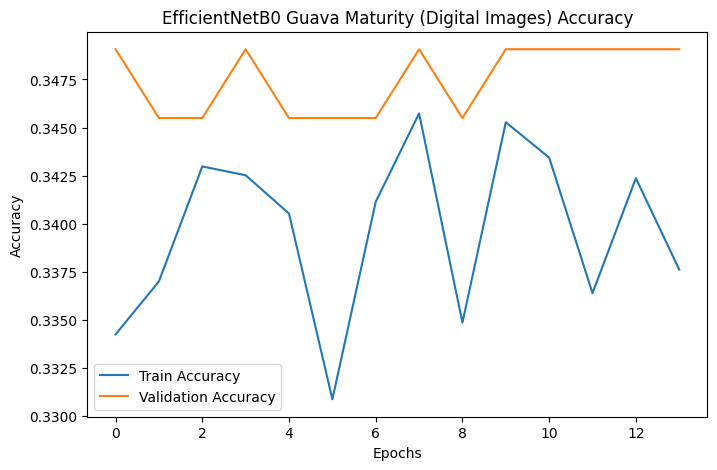

In [1]:
# ============================================================
# 🍃 Guava Maturity Classification using EfficientNetB0 (Digital Images)
# ============================================================

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import os

# ============================================================
# Dataset Paths (UPDATE these paths to your digital dataset)
# ============================================================
train_dir = r"C:\Users\cl502_15\Downloads\Mtech Major Project\Mtech Major Project\Dataset\Maturity\train test val split for digital\train"
val_dir   = r"C:\Users\cl502_15\Downloads\Mtech Major Project\Mtech Major Project\Dataset\Maturity\train test val split for digital\val"
test_dir  = r"C:\Users\cl502_15\Downloads\Mtech Major Project\Mtech Major Project\Dataset\Maturity\train test val split for digital\test"

# ============================================================
# Image Parameters
# ============================================================
img_size = (224, 224)
batch_size = 32
epochs = 50

# ============================================================
# Data Generators
# ============================================================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen  = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# ============================================================
# Model Definition — EfficientNetB0
# ============================================================
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Custom classifier head
x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.4)(x)
output = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile model
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ============================================================
# Callbacks
# ============================================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_efficientnet_digital_guava.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    verbose=1,
    min_lr=1e-6
)

# ============================================================
# Training
# ============================================================
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

# ============================================================
# Evaluation on Test Set
# ============================================================
test_loss, test_acc = model.evaluate(test_gen)
print(f"\n✅ Test Accuracy: {test_acc*100:.2f}%")
print(f"✅ Test Loss: {test_loss:.4f}")

# ============================================================
# Save Final Model
# ============================================================
model.save("efficientnetB0_digital_guava_final.h5")
print("💾 Model saved as 'efficientnetB0_digital_guava_final.h5'")

# ============================================================
# Plot Accuracy
# ============================================================
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('EfficientNetB0 Guava Maturity (Digital Images) Accuracy')
plt.show()

In [2]:
# ============================================================
# ✅ Training Accuracy Summary
# ============================================================

final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"📊 Final Training Accuracy: {final_train_acc * 100:.2f}%")
print(f"📊 Final Validation Accuracy: {final_val_acc * 100:.2f}%")

📊 Final Training Accuracy: 33.76%
📊 Final Validation Accuracy: 34.91%


In [3]:
# ============================================================
# ✅ Evaluate Model on Test Data
# ============================================================
test_loss, test_acc = model.evaluate(test_gen)
print("\n📊 ================================")
print(f"✅ Test Accuracy: {test_acc * 100:.2f}%")
print(f"✅ Test Loss: {test_loss:.4f}")
print("📊 ================================")

44/44 ━━━━━━━━━━━━━━━━━━━━ 70s 2s/step - accuracy: 0.3490 - loss: 1.0970

📊 ================================
✅ Test Accuracy: 34.90%
✅ Test Loss: 1.0970
📊 ================================


✅ Model loaded successfully!
Found 6531 images belonging to 3 classes.
205/205 ━━━━━━━━━━━━━━━━━━━━ 334s 2s/step - accuracy: 0.3491 - loss: 1.0969

🎯 Test Accuracy: 34.91%
📉 Test Loss: 1.0969
205/205 ━━━━━━━━━━━━━━━━━━━━ 385s 2s/step

📊 Classification Report (Test Data):
              precision    recall  f1-score   support

    immature       0.35      1.00      0.52      2280
      mature       0.00      0.00      0.00      2257
 semi_mature       0.00      0.00      0.00      1994

    accuracy                           0.35      6531
   macro avg       0.12      0.33      0.17      6531
weighted avg       0.12      0.35      0.18      6531



c:\Users\cl502_15\AppData\Local\anaconda3\envs\pytorch_env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cl502_15\AppData\Local\anaconda3\envs\pytorch_env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cl502_15\AppData\Local\anaconda3\envs\pytorch_env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

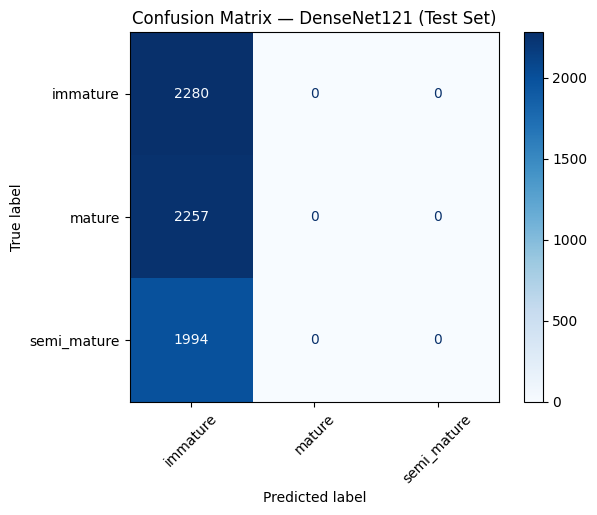

In [1]:
# ============================================================
# 🍃 DenseNet121 — Testing Accuracy Evaluation (Digital Images)
# ============================================================

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ============================================================
# Paths
# ============================================================
test_dir = r"C:\Users\cl502_15\Downloads\Mtech Major Project\Mtech Major Project\Dataset\Maturity\train test val split for digital\train"
model_path = r"C:\Users\cl502_15\Downloads\Mtech Major Project\Mtech Major Project\DeepLearningModels\efficientnetB0_digital_guava_final.h5" # or use "densenet121_digital_guava_final.h5"

# ============================================================
# Load Model
# ============================================================
model = load_model(model_path)
print("✅ Model loaded successfully!")

# ============================================================
# Test Data Generator
# ============================================================
img_size = (224, 224)
batch_size = 32

test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# ============================================================
# Evaluate on Test Set
# ============================================================
test_loss, test_acc = model.evaluate(test_gen)
print(f"\n🎯 Test Accuracy: {test_acc*100:.2f}%")
print(f"📉 Test Loss: {test_loss:.4f}")

# ============================================================
# Predictions & Detailed Metrics
# ============================================================
y_pred = model.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

# Classification Report
print("\n📊 Classification Report (Test Data):")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix — DenseNet121 (Test Set)")
plt.show()